In [ ]:
def obtener_datos(u ,e ,a1, a2, b1, b2, C, type='ARX'):
  N = len(u)
  y = np.zeros_like(u)
  for k in range(2, N):
    y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1]

  return y

Control con los parametros identificados

In [ ]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 24.9 MB/s eta 0:00:00


[0.94649272+0.07368332j 0.94649272-0.07368332j]
[0.93592746+0.04109208j 0.93592746-0.04109208j]
<TransferFunction>: sys[9]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  0.00995
  --------
  z - 0.99
1 states have been removed from the model
Controlador por IMC: <TransferFunction>: sys[20]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

  395.1 z^2 - 739.6 z + 346.8
  ---------------------------
            z^2 - z
1 states have been removed from the model
<TransferFunction>: Sistema de LC
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

   0.01356 z^2 - 0.02538 z + 0.0119
  ----------------------------------
  z^3 - 2.879 z^2 + 2.769 z - 0.8894


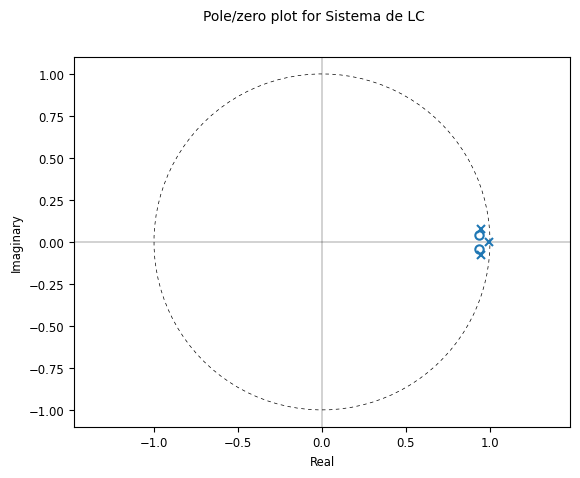

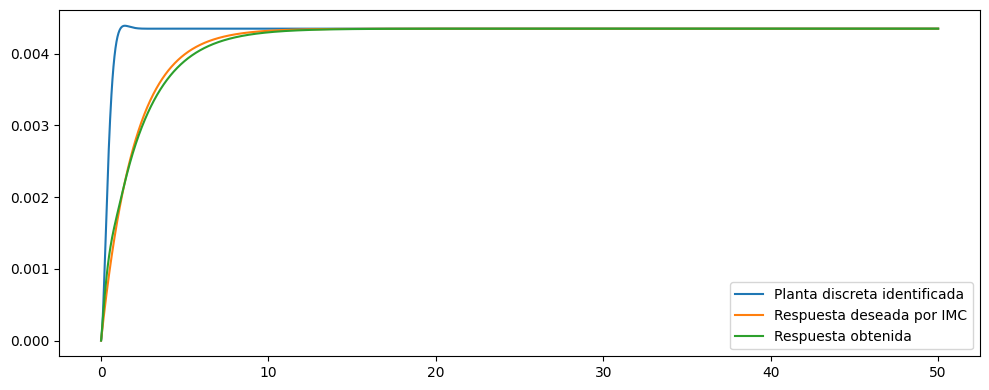

In [ ]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
# Formamos la TF discreta identificada: B(z)/A(z)
# A(z) = 1 + a1 z^-1 + a2 z^-2
# B(z) =      0 + b1 z^-1 + b2 z^-2  (el término z^0 es cero)
a1 = 1.8929854463139977
a2 = -0.9012777069124254
b1 = 3.4320353114814736e-05
b2 = 0

Ts = 0.02
A_d = [1.0, -a1, -a2]
B_d = [0.0, b1, b2]
Gd = ctrl.TransferFunction(B_d, A_d, Ts)
Gd.name="Planta"
print(ctrl.poles(Gd))


a1_id = 1.8718549180000001
a2_id = -0.8776487672200001
b1_id = 2.5182909941999998e-05
b2_id = 0

Ts = 0.02
A_d = [1.0, -a1_id, -a2_id]
B_d = [0.0, b1_id, b2_id]
Gd_id = ctrl.TransferFunction(B_d, A_d, Ts)
Gd_id.name="Planta identificada"
print(ctrl.poles(Gd_id))
ta,ya = ctrl.step_response(Gd_id,50)


# Terminó la identificación: hago el ajuste del control IMC

# Calculo el modelo deseado
beta = 2
s = ctrl.TransferFunction.s
F = 1/(beta*s+1)

Fd = ctrl.c2d(F,Ts,method='zoh')
timc,yimc = ctrl.step_response(Fd*ya[-1],50)
print(Fd)

# Inversa de la planta discreta (pseudo-inversa)
Cd = ctrl.minreal(Fd/(1-Fd)/Gd_id)
print("Controlador por IMC:",Cd)

# Simulación
Gd_cl = ctrl.minreal(ctrl.feedback(ctrl.series(Cd, Gd), 1))
Gd_cl.name='Sistema de LC'
print(Gd_cl)
ctrl.pzmap(Gd_cl)

tcl, ycl = ctrl.step_response(Gd_cl*ya[-1], T=50)

plt.figure(figsize=(10,4))
#tc,yc = ctrl.step_response(Gc,50)

#plt.plot(tc,yc,label='Planta continua')
plt.plot(ta,ya,label='Planta discreta identificada')
plt.plot(timc,yimc,label='Respuesta deseada por IMC')
plt.plot(tcl,ycl,label='Respuesta obtenida')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()

#Primer experimento (identificacion en 0.45 rad)

In [ ]:
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_a1.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_a2.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_b1.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Kp.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Ki.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Kd.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_input.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 98738  100 98738    0     0   221k      0 --:--:-- --:--:-- --:--:--  222k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 89491  100 89491    0     0   203k      0 --:--:-- --:--:-- --:--:--  203k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   99k  100   99k    0     0   141k      0 --:--:-- --:--:-- --:--:--  141k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  119k  100  119k    0     0   292k      0 --:--:-- --:--:-- --:--:--  293k
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
y = np.loadtxt('experimento_0_45_perturbaciones.csv')
a1 = np.loadtxt('experimento_0_45_perturbaciones_a1.csv')
a2 = np.loadtxt('experimento_0_45_perturbaciones_a2.csv')
b1 = np.loadtxt('experimento_0_45_perturbaciones_b1.csv')
Kp = np.loadtxt('experimento_0_45_perturbaciones_Kp.csv')
Ki = np.loadtxt('experimento_0_45_perturbaciones_Ki.csv')
Kd = np.loadtxt('experimento_0_45_perturbaciones_Kd.csv')
u = np.loadtxt('experimento_0_45_perturbaciones_input.csv')

In [ ]:
def lazo_cerrado(r, a1, a2, b1, Kp, Ki, Kd, gamma, N):
  dt = 0.02
  u = 0
  error = 0
  D = 0
  I = 0
  salida = []
  y = np.zeros(N)
  u = np.zeros(N)

  for k in range(2,N):
    error_anterior = error
    error = r[k] - y[k-1]

    D = (2/dt)*(error - error_anterior)*(1/(2/dt + 1)) - D * ((1 - (2/dt * gamma)) / (2/dt + 1))

    # Integrador trapezoidal
    I = I + (dt/2)*error + (dt/2)*error_anterior

    # Términos PID
    termino_1 = Kp * error
    termino_2 = Ki * I
    termino_3 = Kd * D
    # termino_3 = Kd * (2*(error - error_anterior)/dt - D)  # alternativa comentada
    u[k] = termino_1 + termino_2 + termino_3

    y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1]

  return y, u


##Rtas al escalon

<TransferFunction>: sys[34]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

   0.006644
  ----------
  z - 0.9934


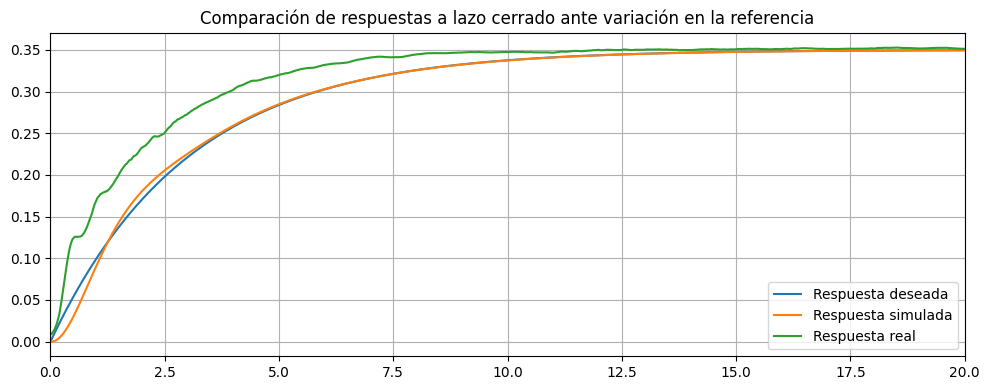

In [ ]:
beta = 2
N = 3000

a1_obtenido = a1[-1]
a2_obtenido = a2[-1]
b1_obtenido = b1[-1]

Kp_obtenido = Kp[-1]
Ki_obtenido = Ki[-1]
Kd_obtenido = Kd[-1]

ref = 0.45 - 0.1

y_sim, u_sim = lazo_cerrado(np.repeat(ref,N), a1_obtenido, a2_obtenido, b1_obtenido, Kp_obtenido, Ki_obtenido, Kd_obtenido, Ts, N)

t_sim = np.linspace(0, N*Ts, N)


beta = 3
s = ctrl.TransferFunction.s
F = 1/(beta*s+1)

Fd = ctrl.c2d(F,Ts,method='zoh')
timc,yimc = ctrl.step_response(Fd*ref,50)
print(Fd)

plt.figure(figsize=(10,4))
plt.plot(timc,yimc)
plt.plot(t_sim, y_sim)
plt.title('Comparación de respuestas a lazo cerrado ante variación en la referencia')
t = np.linspace(0, len(y[3210:5400])*Ts, len(y[3210:5400]))
plt.plot(t, y[3210:5400]-0.1)
plt.legend(['Respuesta deseada', 'Respuesta simulada',  'Respuesta real'])
plt.xlim([0,20])
plt.grid(True)
plt.tight_layout()
plt.show()

##Parámetros estimados

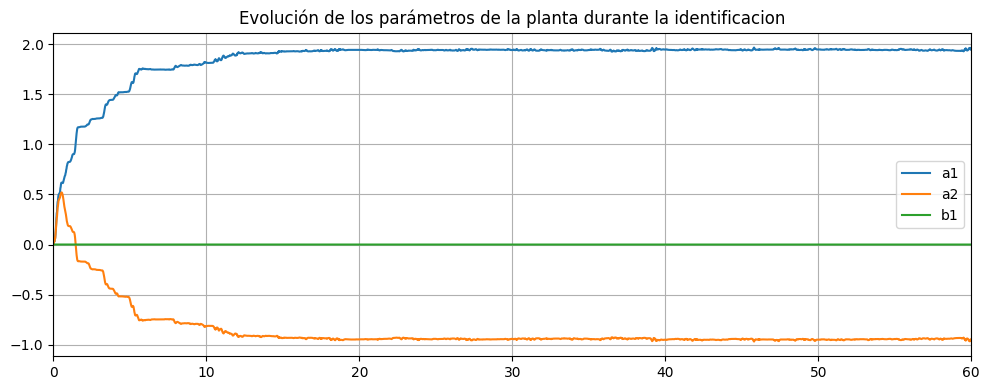

In [ ]:
plt.figure(figsize=(10,4))
t = np.linspace(0, len(a1)*Ts, len(a1))
plt.title('Evolución de los parámetros de la planta durante la identificacion')
plt.plot(t,a1)
plt.plot(t,a2)
plt.plot(t,b1)
plt.legend(['a1', 'a2',  'b1'])
plt.xlim([0,60])
plt.grid(True)
plt.tight_layout()
plt.show()

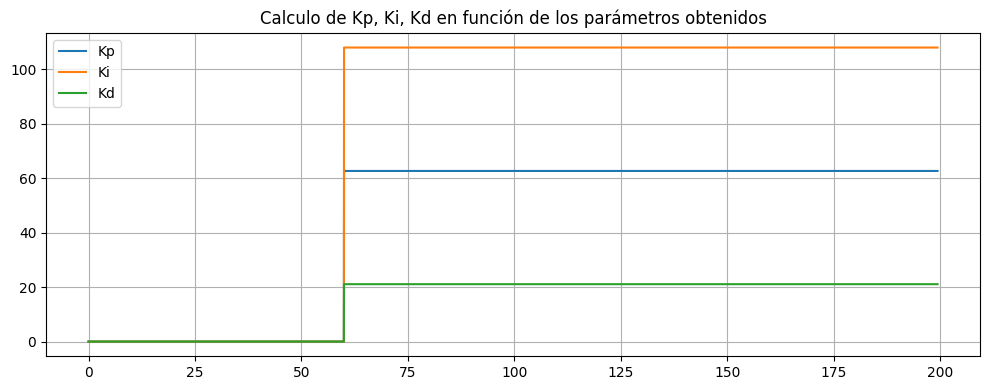

In [ ]:
plt.figure(figsize=(10,4))
t = np.linspace(0, len(a1)*Ts, len(a1))
plt.title('Calculo de Kp, Ki, Kd en función de los parámetros obtenidos')
plt.plot(t,Kp)
plt.plot(t,Ki)
plt.plot(t,Kd)
plt.legend(['Kp', 'Ki',  'Kd'])

plt.grid(True)
plt.tight_layout()
plt.show()

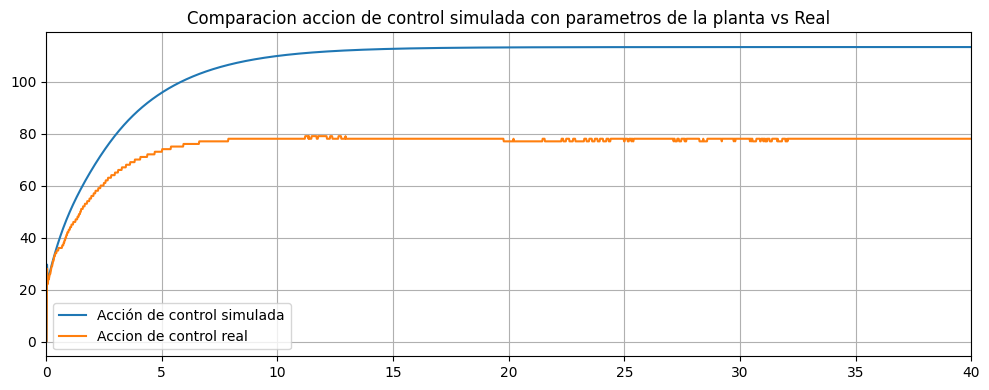

In [ ]:
plt.figure(figsize=(10,4))
t = np.linspace(0, len(u[3197:5400])*Ts, len(u[3197:5400]))
plt.title('Comparacion accion de control simulada con parametros de la planta vs Real')
plt.plot(t_sim,u_sim)
plt.plot(t,u[3197:5400])
plt.xlim([0,40])
plt.legend(['Acción de control simulada', 'Accion de control real'])

plt.grid(True)
plt.tight_layout()
plt.show()

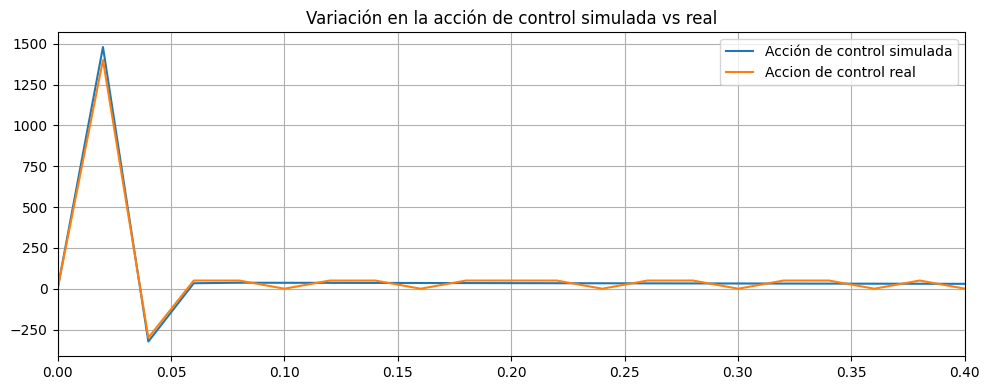

In [ ]:
u_obj = u[3197:5400]
deltau = np.zeros(len(u_obj))
deltau_sim = np.zeros(len(u_sim))
for k in range(len(u_obj)-1):
  deltau[k] = (u_obj[k+1] - u_obj[k])/Ts
  deltau_sim[k] = (u_sim[k+1] - u_sim[k])/Ts

plt.figure(figsize=(10,4))
t = np.linspace(0, len(u[3197:5400])*Ts, len(u[3197:5400]))
plt.title('Variación en la acción de control simulada vs real')
plt.plot(t_sim,deltau_sim)
plt.plot(t,deltau)
plt.xlim([0,0.4])
plt.legend(['Acción de control simulada', 'Accion de control real'])

plt.grid(True)
plt.tight_layout()
plt.show()


##Perturbaciones



#Varios escalones

In [ ]:
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_escalones.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_escalones_ref.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_escalones_input.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  100k  100  100k    0     0   141k      0 --:--:-- --:--:-- --:--:--  141k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48745  100 48745    0     0  89451      0 --:--:-- --:--:-- --:--:-- 89440
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 32714  100 32714    0     0  50531      0 --:--:-- --:--:-- --:--:-- 50562


In [ ]:
ref = np.loadtxt('experimento_0_45_escalones_ref.csv')
y = np.loadtxt('experimento_0_45_escalones.csv')
u = np.loadtxt('experimento_0_45_escalones_input.csv')

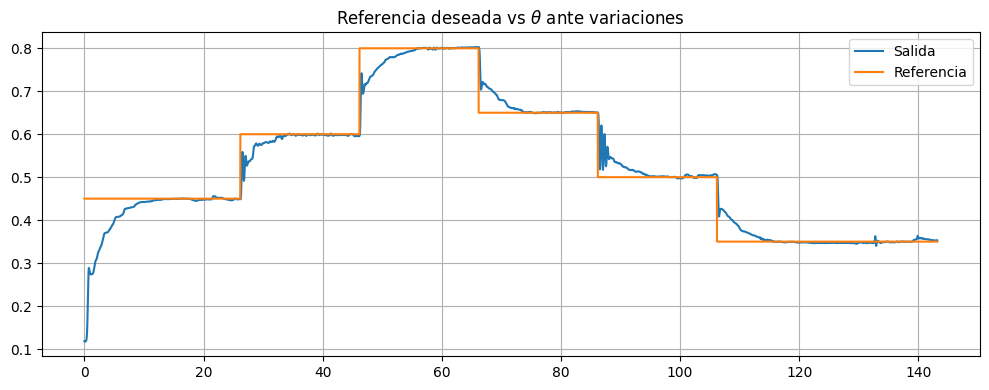

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.title(r'Referencia deseada vs $\theta$ ante variaciones')
plt.plot(t, y[3190:])
plt.plot(t, ref[3190:])
plt.legend(['Salida', 'Referencia'])
plt.grid(True)
plt.tight_layout()
plt.show()

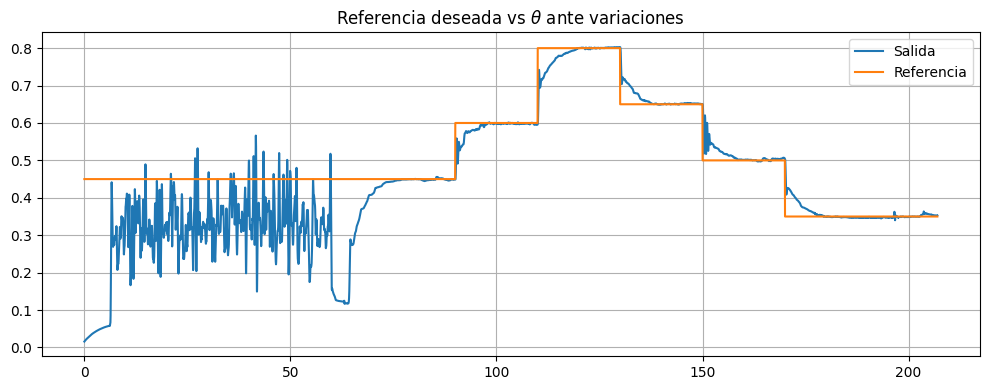

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u)*Ts, len(u))
plt.title(r'Referencia deseada vs $\theta$ ante variaciones')
plt.plot(t, y)
plt.plot(t, ref)
plt.legend(['Salida', 'Referencia'])
plt.grid(True)
plt.tight_layout()
plt.show()

##**Perturbaciones**

In [ ]:
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_a1.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_a2.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_b1.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Kp.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Ki.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_Kd.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_45_perturbaciones_input.csv
y = np.loadtxt('experimento_0_45_perturbaciones.csv')
a1 = np.loadtxt('experimento_0_45_perturbaciones_a1.csv')
a2 = np.loadtxt('experimento_0_45_perturbaciones_a2.csv')
b1 = np.loadtxt('experimento_0_45_perturbaciones_b1.csv')
Kp = np.loadtxt('experimento_0_45_perturbaciones_Kp.csv')
Ki = np.loadtxt('experimento_0_45_perturbaciones_Ki.csv')
Kd = np.loadtxt('experimento_0_45_perturbaciones_Kd.csv')
u = np.loadtxt('experimento_0_45_perturbaciones_input.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 98738  100 98738    0     0   375k      0 --:--:-- --:--:-- --:--:--  376k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 89491  100 89491    0     0   314k      0 --:--:-- --:--:-- --:--:--  314k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   99k  100   99k    0     0   300k      0 --:--:-- --:--:-- --:--:--  301k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  119k  100  119k    0     0   489k      0 --:--:-- --:--:-- --:--:--  490k
  % Total    % Received % Xferd  Average Speed   Tim

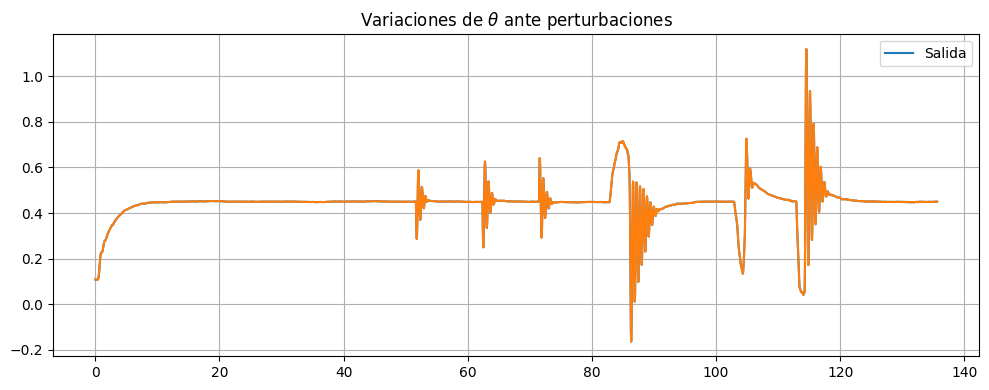

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.title(r'Variaciones de $\theta$ ante perturbaciones')
plt.plot(t, y[3190:])
t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.plot(t, y[3190:])

plt.legend(['Salida'])
plt.grid(True)
plt.tight_layout()
plt.show()

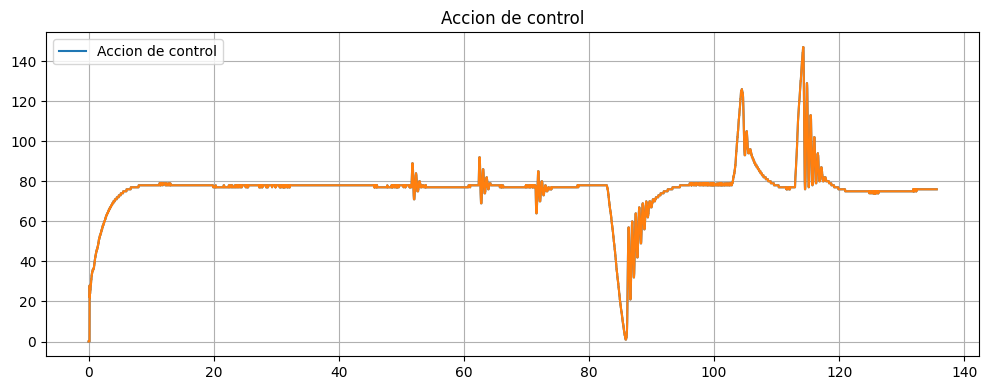

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.title(r'Accion de control')
plt.plot(t, u[3190:])
t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.plot(t, u[3190:])

plt.legend(['Accion de control'])
plt.grid(True)
plt.tight_layout()
plt.show()

##*0.6 tita*

##**Escalon**

##**Perturbaciones**

In [ ]:
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_a1.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_a2.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_ref.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_Kp.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_Ki.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_Kd.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_perturbaciones_input.csv
y = np.loadtxt('experimento_0_6_perturbaciones.csv')
a1 = np.loadtxt('experimento_0_6_perturbaciones_a1.csv')
a2 = np.loadtxt('experimento_0_6_perturbaciones_a2.csv')
ref = np.loadtxt('experimento_0_6_perturbaciones_ref.csv')
Kp = np.loadtxt('experimento_0_6_perturbaciones_Kp.csv')
Ki = np.loadtxt('experimento_0_6_perturbaciones_Ki.csv')
Kd = np.loadtxt('experimento_0_6_perturbaciones_Kd.csv')
u = np.loadtxt('experimento_0_6_perturbaciones_input.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  125k  100  125k    0     0   229k      0 --:--:-- --:--:-- --:--:--  229k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  114k  100  114k    0     0   147k      0 --:--:-- --:--:-- --:--:--  147k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  139k  100  139k    0     0   135k      0  0:00:01  0:00:01 --:--:--  136k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48215  100 48215    0     0  65744      0 --:--:-- --:--:-- --:--:-- 65957
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
y = np.loadtxt('experimento_0_6_perturbaciones.csv')
a1 = np.loadtxt('experimento_0_6_perturbaciones_a1.csv')
a2 = np.loadtxt('experimento_0_6_perturbaciones_a2.csv')
ref = np.loadtxt('experimento_0_6_perturbaciones_ref.csv')
Kp = np.loadtxt('experimento_0_6_perturbaciones_Kp.csv')
Ki = np.loadtxt('experimento_0_6_perturbaciones_Ki.csv')
Kd = np.loadtxt('experimento_0_6_perturbaciones_Kd.csv')
u = np.loadtxt('experimento_0_6_perturbaciones_input.csv')

<TransferFunction>: sys[45]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

   0.006644
  ----------
  z - 0.9934


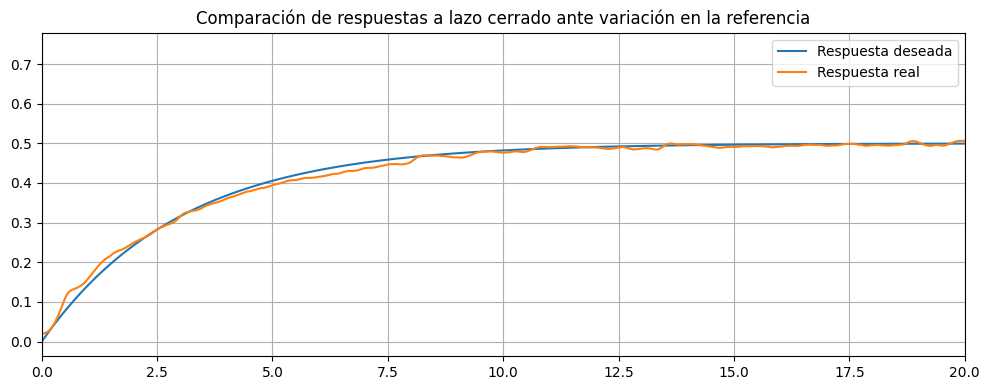

In [ ]:
beta = 2
N = 3000

a1_obtenido = a1[-1]
a2_obtenido = a2[-1]
Kp_obtenido = Kp[-1]
Ki_obtenido = Ki[-1]
Kd_obtenido = Kd[-1]

ref = 0.6 - 0.1

t_sim = np.linspace(0, N*Ts, N)


beta = 3
s = ctrl.TransferFunction.s
F = 1/(beta*s+1)

Fd = ctrl.c2d(F,Ts,method='zoh')
timc,yimc = ctrl.step_response(Fd*ref,50)
print(Fd)

plt.figure(figsize=(10,4))
plt.plot(timc,yimc)
plt.title('Comparación de respuestas a lazo cerrado ante variación en la referencia')
t = np.linspace(0, len(y[3210:5400])*Ts, len(y[3210:5400]))
plt.plot(t, y[3210:5400]-0.1)
plt.legend(['Respuesta deseada','Respuesta real'])
plt.xlim([0,20])
plt.grid(True)
plt.tight_layout()
plt.show()

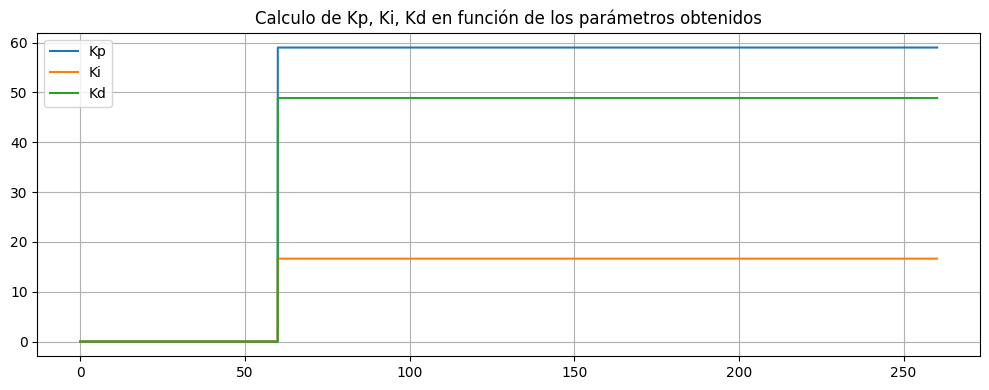

In [ ]:
plt.figure(figsize=(10,4))
t = np.linspace(0, len(a1)*Ts, len(a1))
plt.title('Calculo de Kp, Ki, Kd en función de los parámetros obtenidos')
plt.plot(t,Kp)
plt.plot(t,Ki)
plt.plot(t,Kd)
plt.legend(['Kp', 'Ki',  'Kd'])

plt.grid(True)
plt.tight_layout()
plt.show()

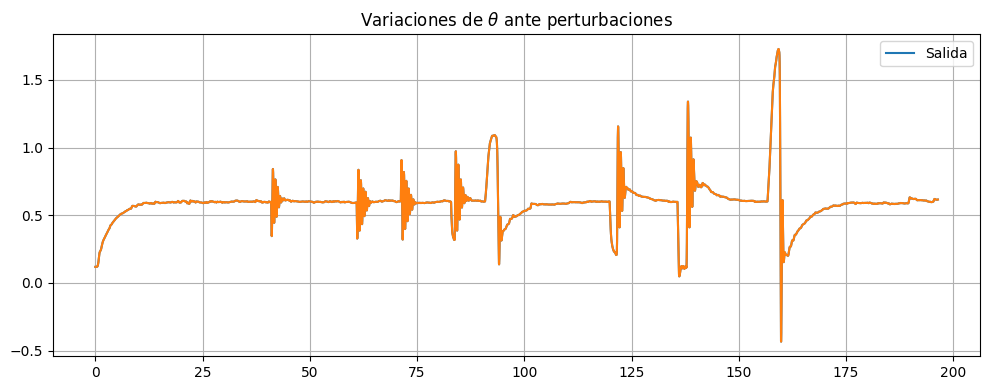

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.title(r'Variaciones de $\theta$ ante perturbaciones')
plt.plot(t, y[3190:])
t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.plot(t, y[3190:])

plt.legend(['Salida'])
plt.grid(True)
plt.tight_layout()
plt.show()

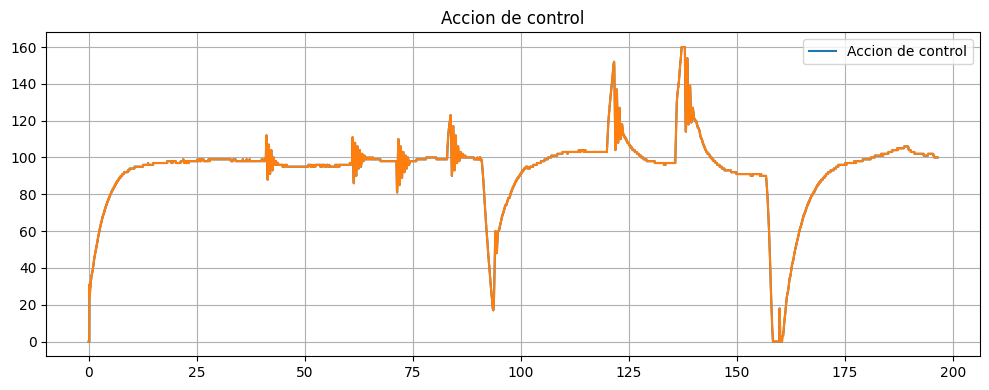

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.title(r'Accion de control')
plt.plot(t, u[3190:])
t = np.linspace(0, len(u[3190:])*Ts, len(u[3190:]))
plt.plot(t, u[3190:])

plt.legend(['Accion de control'])
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_escalones.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_escalones_ref.csv
!curl -JLO https://raw.githubusercontent.com/fadellavedova/control_adaptativo/refs/heads/master/mediciones/experimento_0_6_escalones_input.csv
ref = np.loadtxt('experimento_0_6_escalones_ref.csv')
y = np.loadtxt('experimento_0_6_escalones.csv')
u = np.loadtxt('experimento_0_6_escalones_input.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   99k  100   99k    0     0   238k      0 --:--:-- --:--:-- --:--:--  237k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48215  100 48215    0     0   121k      0 --:--:-- --:--:-- --:--:--  121k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33338  100 33338    0     0  88706      0 --:--:-- --:--:-- --:--:-- 88664


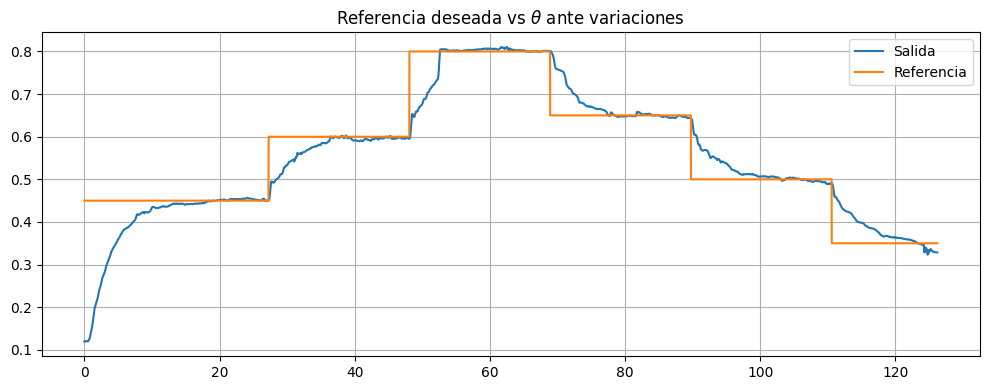

In [ ]:
plt.figure(figsize=(10,4))

t = np.linspace(0, len(u[3190:9500])*Ts, len(u[3190:9250]))
plt.title(r'Referencia deseada vs $\theta$ ante variaciones')
plt.plot(t, y[3190:9250])
plt.plot(t, ref[3190:9250])
plt.legend(['Salida', 'Referencia'])
plt.grid(True)
plt.tight_layout()
plt.show()